In [5]:
import pandas as pd

In [6]:
file_path = "StudentsPerformance.csv"
df = pd.read_csv(file_path)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB
None


In [8]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [11]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [12]:
df.rename(columns={
    "race/ethnicity": "race_ethnicity",
    "parental level of education": "parental_level_of_education",
    "test preparation course": "test_preparation_course",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score",   
    }, inplace=True)
df.columns


Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [13]:
df["gender"].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [14]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [15]:
!poetry add tabulate

The following packages are already present in the pyproject.toml and will be skipped:

  - tabulate

If you want to update it to the latest compatible version, you can use `poetry update package`.
If you prefer to upgrade it to the latest available version, you can use `poetry add package@latest`.

Nothing to add.


In [16]:
from tabulate import tabulate
reading_full = df[df['reading_score'] == 100]
math_full = df[df['math_score'] == 100]
writing_full = df[df['writing_score'] == 100]
print(f"Reading full scores: {reading_full['reading_score'].count()}")
print(tabulate(reading_full, headers='keys', tablefmt='psql'))

print(f"Math full scores: {math_full['math_score'].count()}")
print(tabulate(math_full, headers='keys', tablefmt='psql'))
print()
print(f"Writing full scores: {writing_full['writing_score'].count()}")
print(tabulate(writing_full, headers='keys', tablefmt='psql'))

Reading full scores: 17
+-----+----------+------------------+-------------------------------+--------------+---------------------------+--------------+-----------------+-----------------+
|     | gender   | race_ethnicity   | parental_level_of_education   | lunch        | test_preparation_course   |   math_score |   reading_score |   writing_score |
|-----+----------+------------------+-------------------------------+--------------+---------------------------+--------------+-----------------+-----------------|
| 106 | female   | group D          | master's degree               | standard     | none                      |           87 |             100 |             100 |
| 114 | female   | group E          | bachelor's degree             | standard     | completed                 |           99 |             100 |             100 |
| 149 | male     | group E          | associate's degree            | free/reduced | completed                 |          100 |             100 |           

In [17]:
pass_grade = 50
df['pass_math'] = (df['math_score'] >= pass_grade).map({True: 'pass', False: 'fail'})
df['pass_reading'] = (df['reading_score'] >= pass_grade).map({True: 'pass', False: 'fail'})
df['pass_writing'] = (df['writing_score'] >= pass_grade).map({True: 'pass', False: 'fail'})
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,pass_math,pass_reading,pass_writing
0,female,group B,bachelor's degree,standard,none,72,72,74,pass,pass,pass
1,female,group C,some college,standard,completed,69,90,88,pass,pass,pass
2,female,group B,master's degree,standard,none,90,95,93,pass,pass,pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,fail,pass,fail
4,male,group C,some college,standard,none,76,78,75,pass,pass,pass
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,pass,pass,pass
996,male,group C,high school,free/reduced,none,62,55,55,pass,pass,pass
997,female,group C,high school,free/reduced,completed,59,71,65,pass,pass,pass
998,female,group D,some college,standard,completed,68,78,77,pass,pass,pass


In [18]:
students_not_pass_math = df[df['pass_math'] == "fail"]
print(len(students_not_pass_math))
# print(tabulate(students_not_pass_math, headers='keys', tablefmt='psql'))


snpm_use_groupby = df.groupby('pass_math')['pass_math'].count()
print(snpm_use_groupby)

135
pass_math
fail    135
pass    865
Name: pass_math, dtype: int64


In [19]:
!poetry add matplotlib
!poetry add seaborn

The following packages are already present in the pyproject.toml and will be skipped:

  - matplotlib

If you want to update it to the latest compatible version, you can use `poetry update package`.
If you prefer to upgrade it to the latest available version, you can use `poetry add package@latest`.

Nothing to add.
The following packages are already present in the pyproject.toml and will be skipped:

  - seaborn

If you want to update it to the latest compatible version, you can use `poetry update package`.
If you prefer to upgrade it to the latest available version, you can use `poetry add package@latest`.

Nothing to add.


Math mean: 66.089
Reading mean: 69.169
Writing mean: 68.054


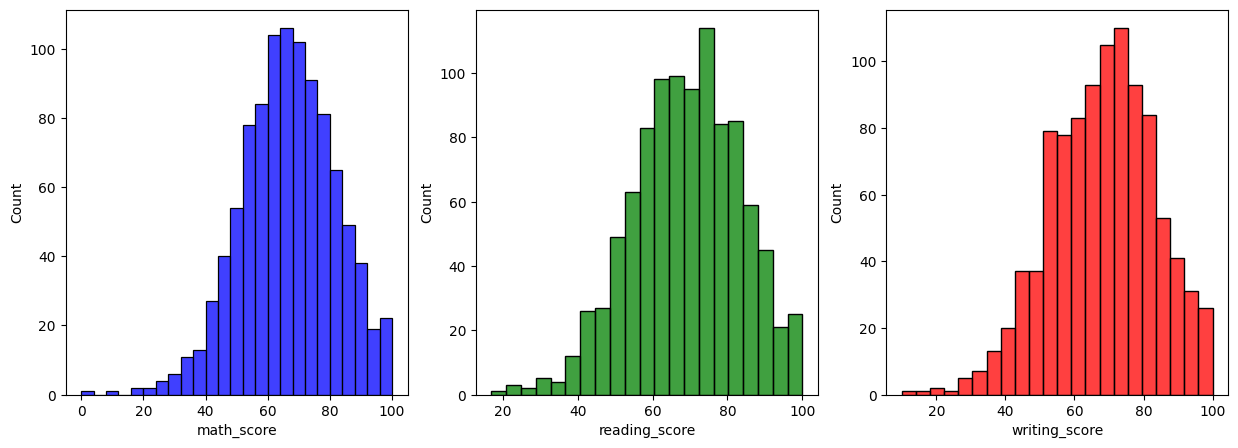

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=df, x="math_score", ax=ax[0], color="blue")
sns.histplot(data=df, x="reading_score", ax=ax[1], color="green")
sns.histplot(data=df, x="writing_score", ax=ax[2], color="red")
math_mean = df["math_score"].mean()
reading_mean = df["reading_score"].mean()
writing_mean = df["writing_score"].mean()
print(f"Math mean: {math_mean}")
print(f"Reading mean: {reading_mean}")
print(f"Writing mean: {writing_mean}")
plt.show()


Pass Math Count:
pass_math
fail    135
pass    865
dtype: int64

Pass Reading Count:
pass_reading
fail     90
pass    910
dtype: int64

Pass Writing Count:
pass_writing
fail    114
pass    886
dtype: int64


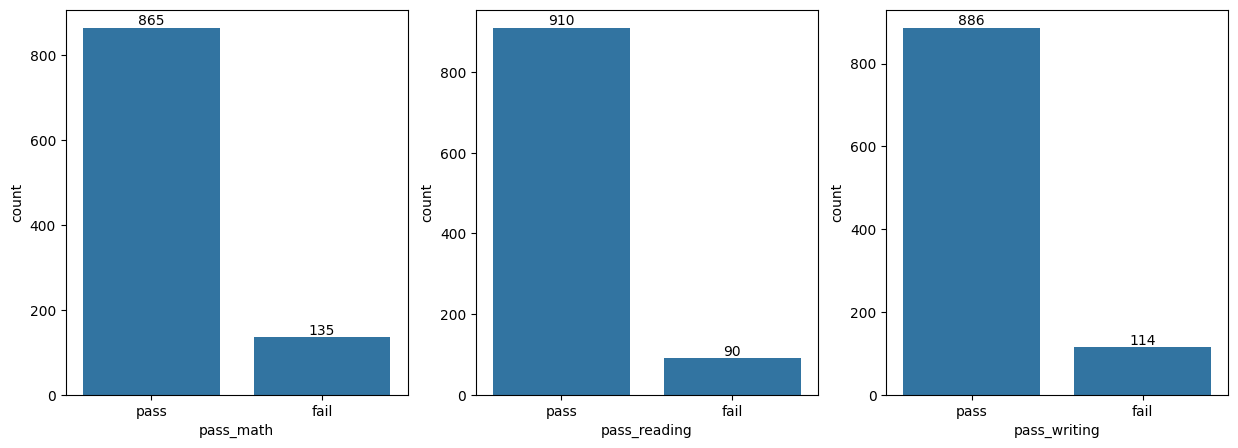

In [21]:
fig1, ax1 = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=df, x='pass_math', ax=ax1[0])
sns.countplot(data=df, x='pass_reading', ax=ax1[1])
sns.countplot(data=df, x='pass_writing', ax=ax1[2])

for _ in ax1:
    for container in _.containers:
        _.bar_label(container)

pass_math_count = df.groupby('pass_math').size()
pass_reading_count = df.groupby('pass_reading').size()
pass_writing_count = df.groupby('pass_writing').size()
print("Pass Math Count:")
print(pass_math_count)
print("\nPass Reading Count:")
print(pass_reading_count)
print("\nPass Writing Count:")
print(pass_writing_count)
plt.show()

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
 8   pass_math                    1000 non-null   str  
 9   pass_reading                 1000 non-null   str  
 10  pass_writing                 1000 non-null   str  
dtypes: int64(3), str(8)
memory usage: 86.1 KB


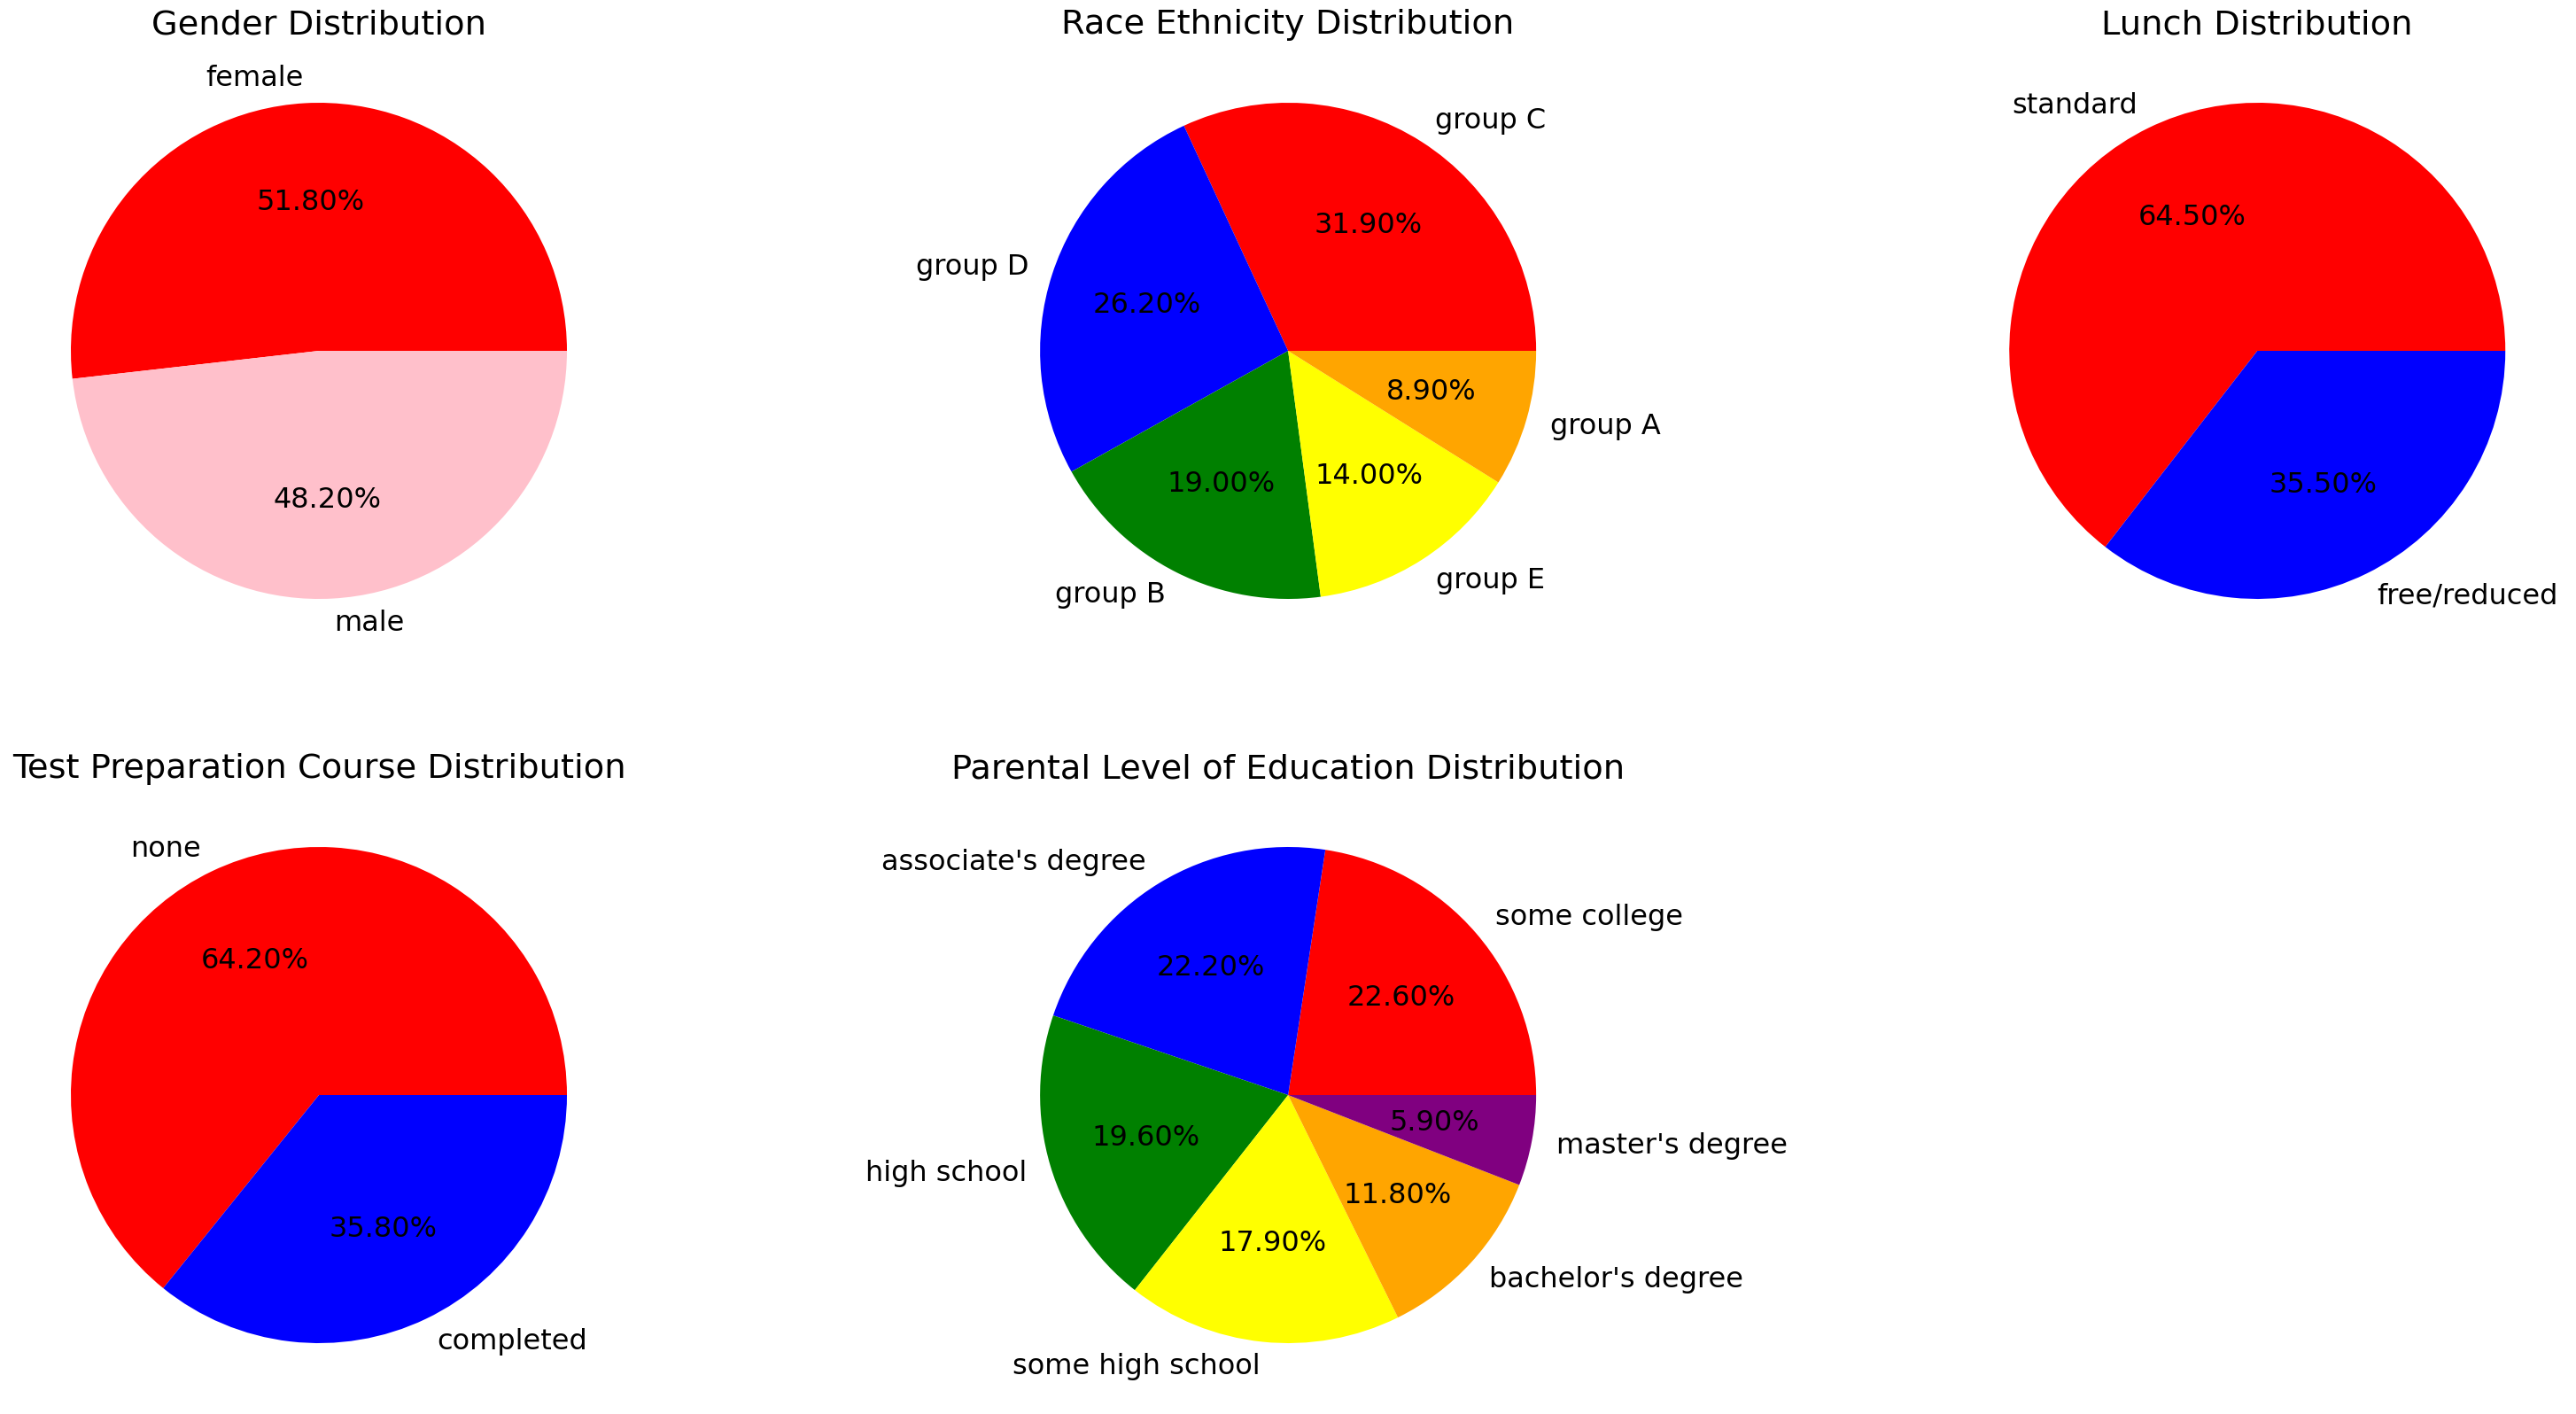

In [23]:
plt.rcParams['figure.figsize'] = (40, 20)
plt.rcParams['font.size'] = 23

plt.subplot(2, 3, 1)
count_gender = df['gender'].value_counts()
colors = ['red', 'pink']
plt.pie(count_gender, labels=count_gender.index, colors=colors, autopct='%.2f%%')
plt.title('Gender Distribution')


plt.subplot(2, 3, 2)
count_re = df['race_ethnicity'].value_counts()
colors = ['red', 'blue', 'green', 'yellow', 'orange']
plt.pie(count_re, labels=count_re.index, colors=colors, autopct='%.2f%%')
plt.title('Race Ethnicity Distribution')


plt.subplot(2, 3, 3)
count_lunch = df['lunch'].value_counts()
colors = ['red', 'blue']
plt.pie(count_lunch, labels=count_lunch.index, colors=colors, autopct='%.2f%%')
plt.title('Lunch Distribution')

plt.subplot(2, 3, 4)

count_tpc = df['test_preparation_course'].value_counts()
colors = ['red', 'blue']
plt.pie(count_tpc, labels=count_tpc.index, colors=colors, autopct='%.2f%%')
plt.title('Test Preparation Course Distribution')


plt.subplot(2, 3, 5)
count_ploe = df['parental_level_of_education'].value_counts()
colors = ['red', 'blue', 'green', 'yellow', 'orange', 'purple']
plt.pie(count_ploe, labels=count_ploe.index, colors=colors, autopct='%.2f%%')
plt.title('Parental Level of Education Distribution')


plt.show()



Text(0.5, 1.0, 'Writing Score')

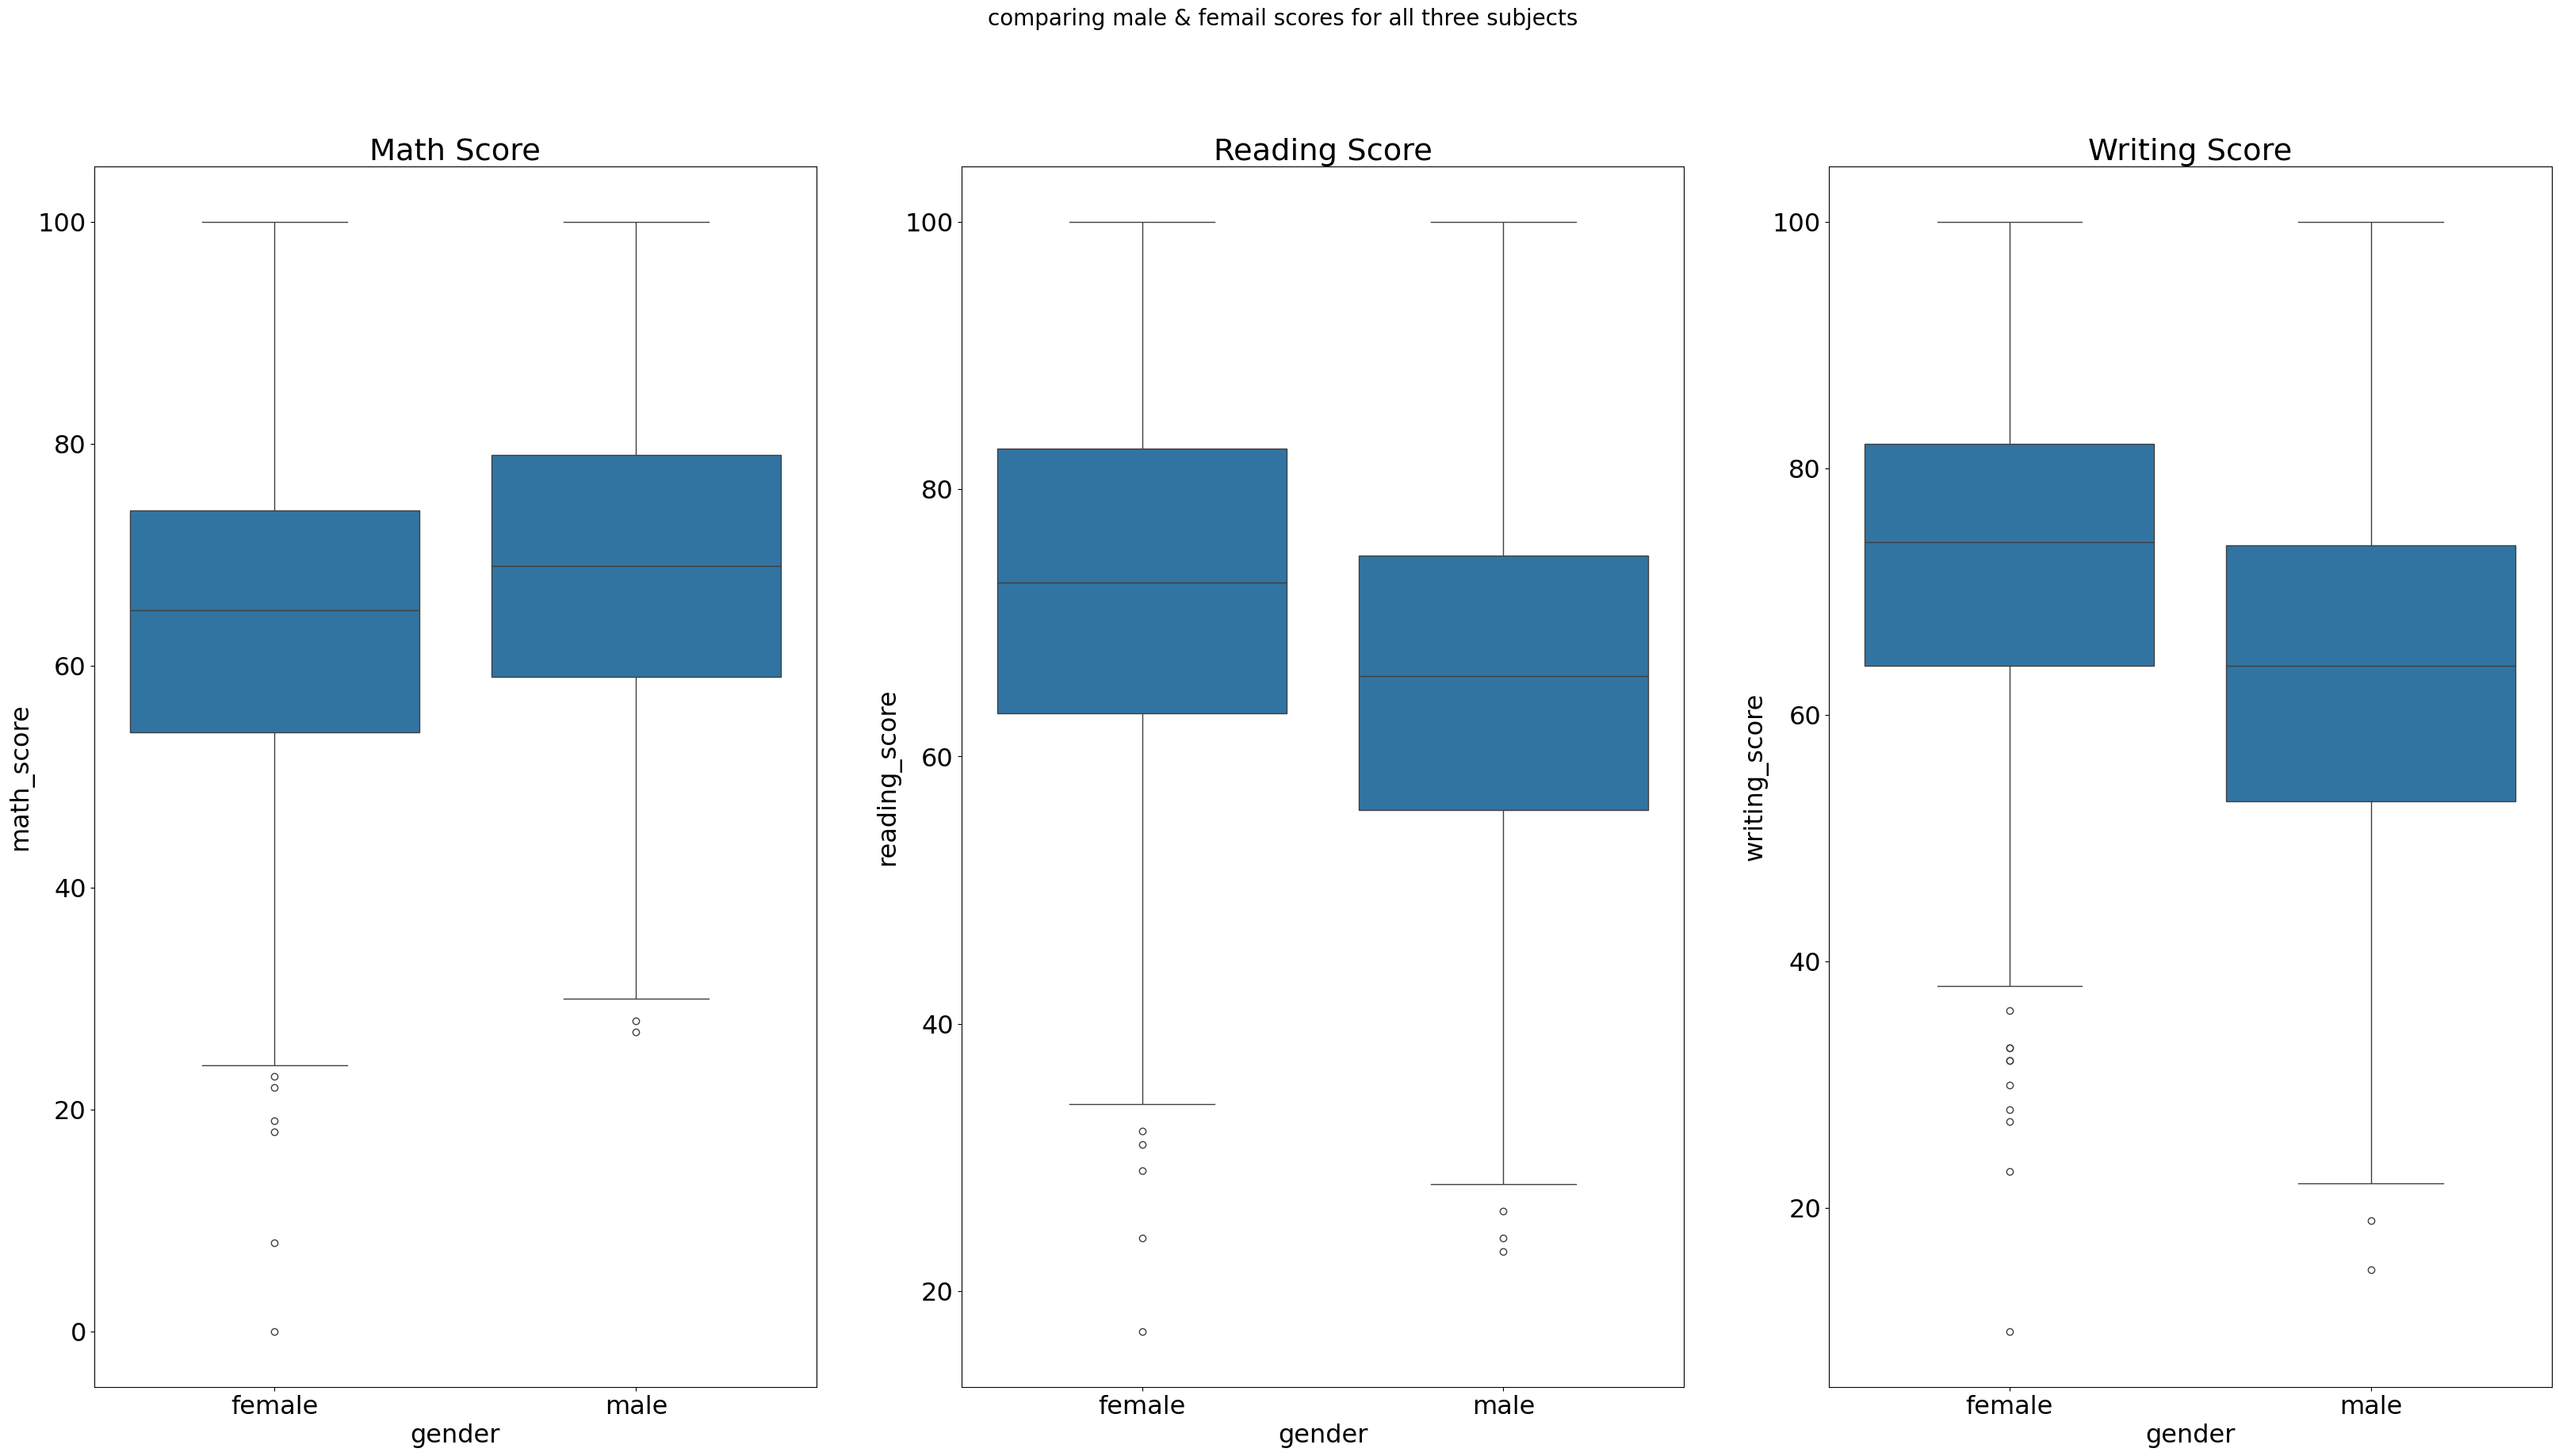

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.suptitle('comparing male & femail scores for all three subjects', fontsize=20)

sns.boxplot(data=df, x='gender', y='math_score', ax=ax1)
ax1.set_title('Math Score')
sns.boxplot(data=df, x='gender', y='reading_score', ax=ax2)
ax2.set_title('Reading Score')
sns.boxplot(data=df, x='gender', y='writing_score', ax=ax3)
ax3.set_title('Writing Score')

/tmp/ipykernel_150106/4182640271.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=rotation)
/tmp/ipykernel_150106/4182640271.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=rotation)
/tmp/ipykernel_150106/4182640271.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=rotation)


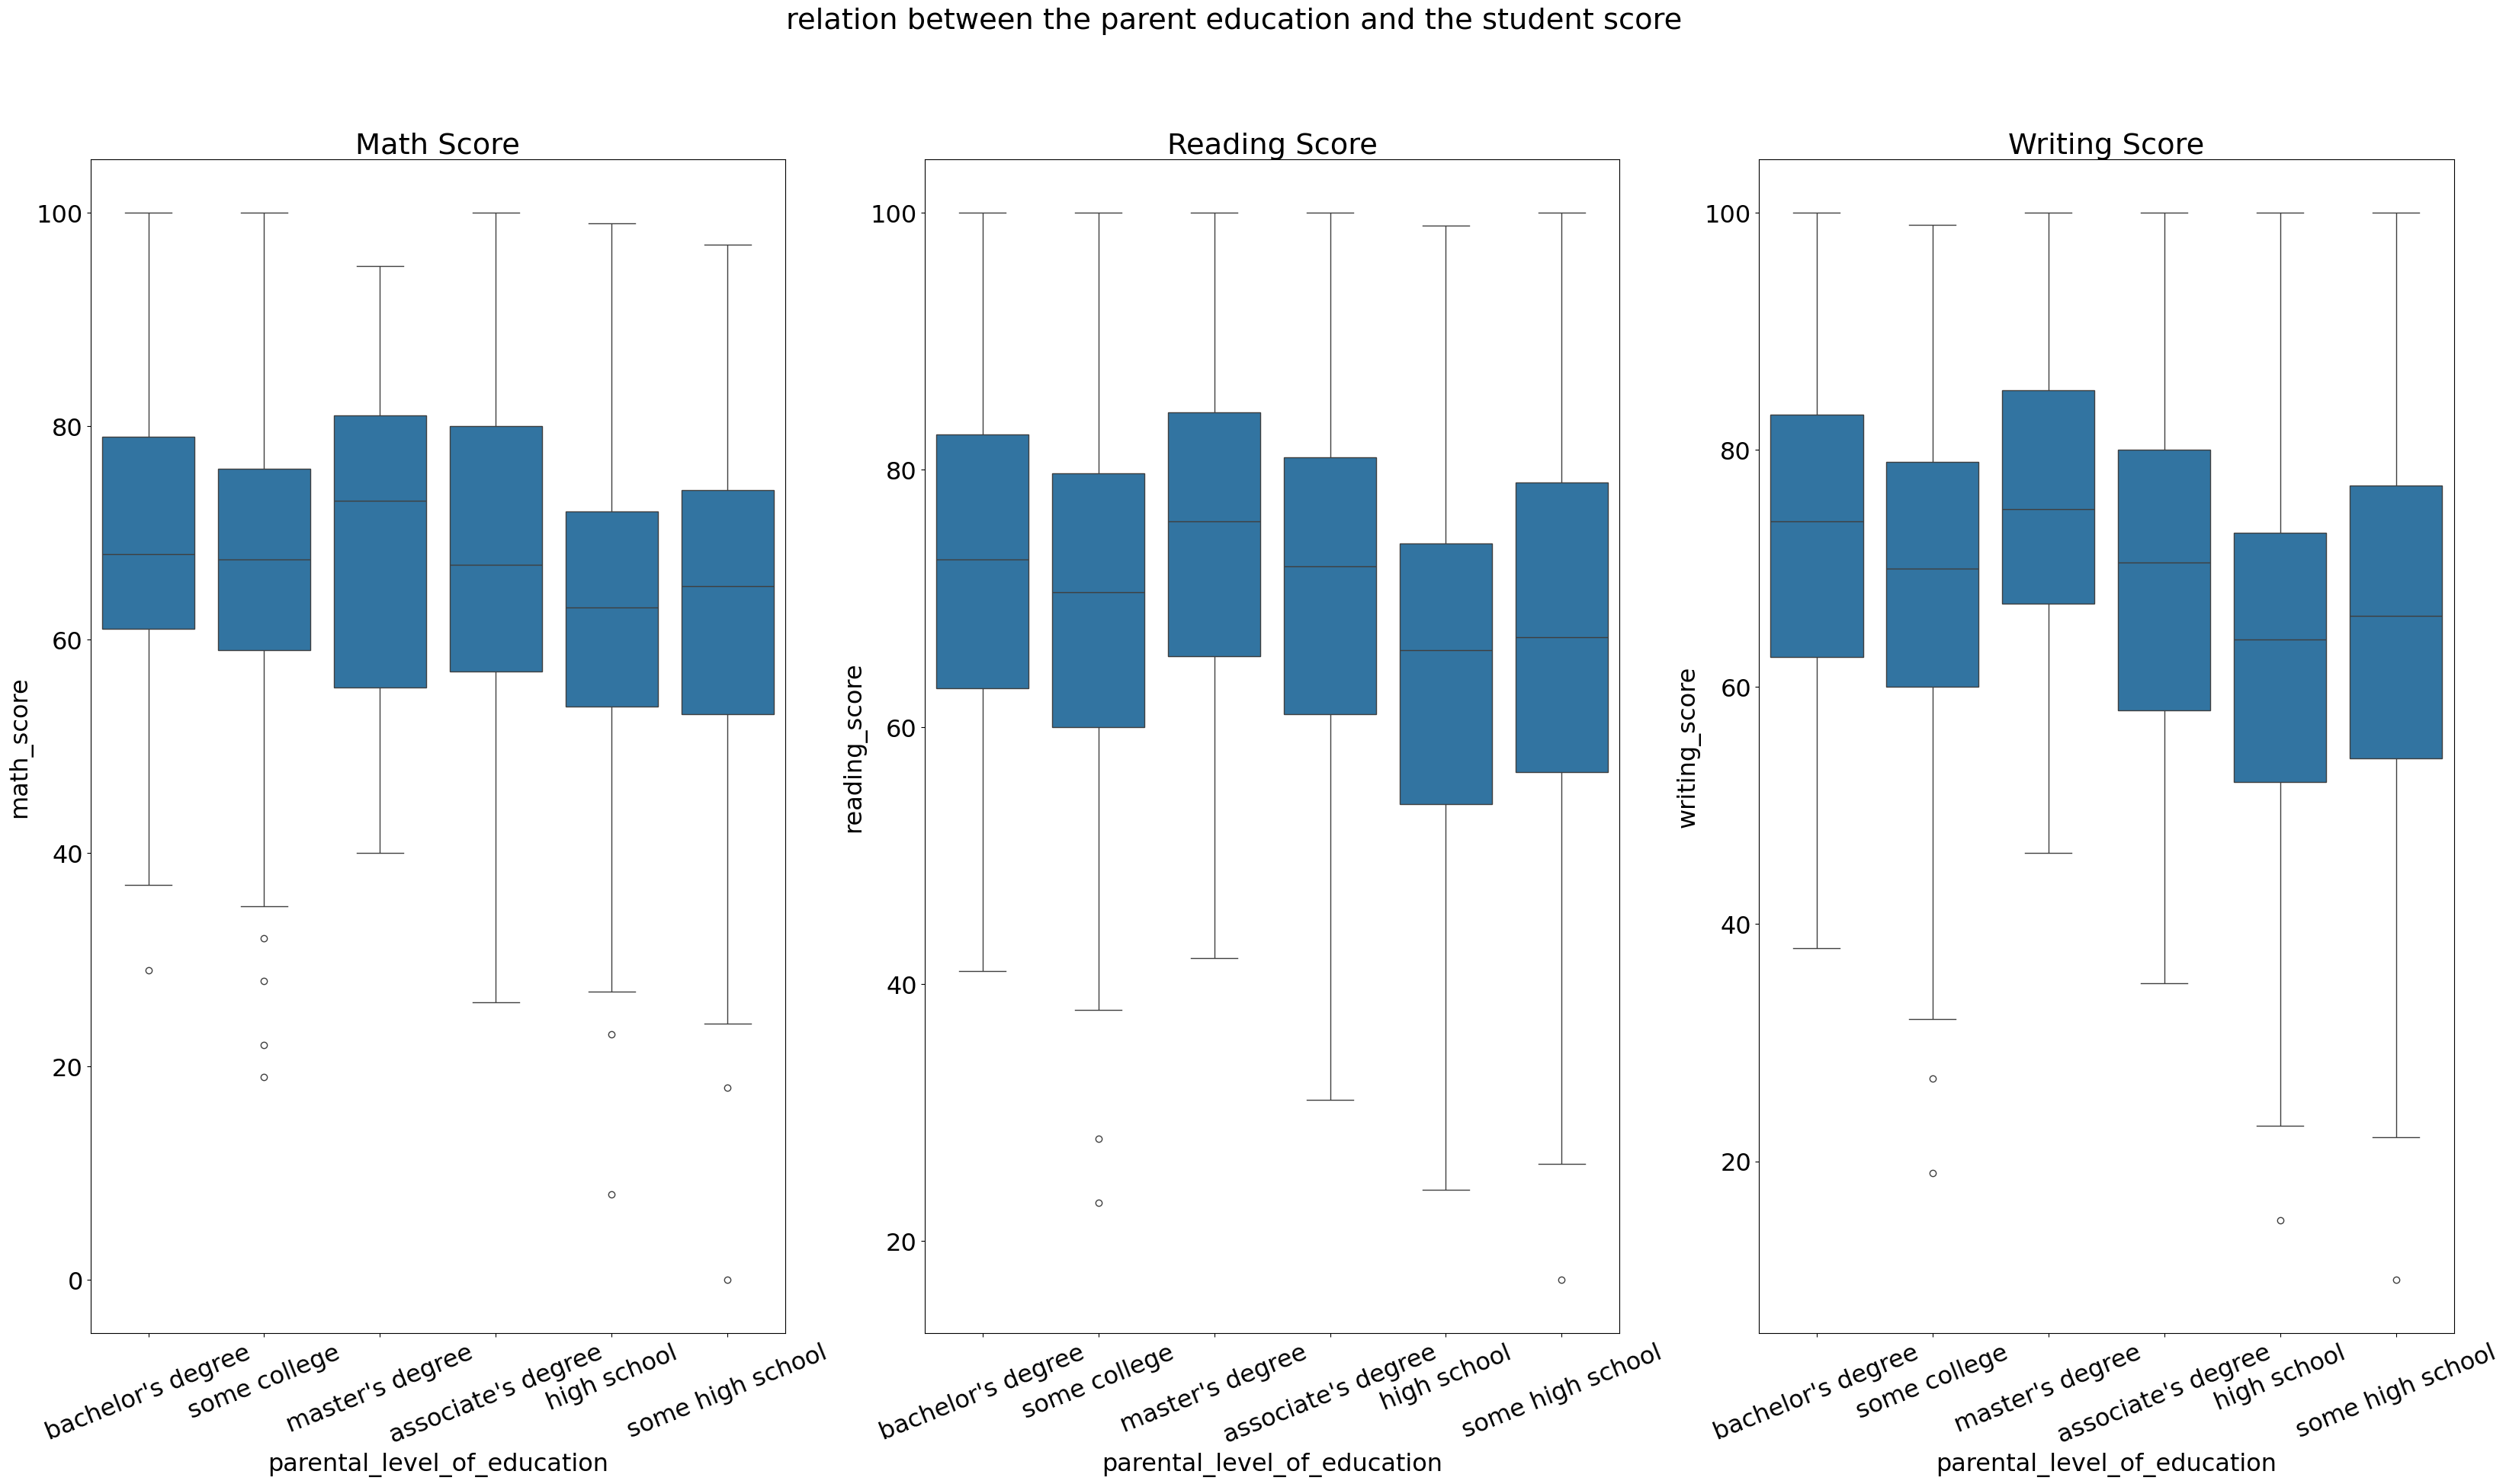

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.suptitle('relation between the parent education and the student score')
rotation = 22
sns.boxplot(data=df, x='parental_level_of_education', y='math_score', ax=ax1)
ax1.set_title('Math Score')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=rotation)
sns.boxplot(data=df, x='parental_level_of_education', y='reading_score', ax=ax2)
ax2.set_title('Reading Score')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=rotation)
sns.boxplot(data=df, x='parental_level_of_education', y='writing_score', ax=ax3)
ax3.set_title('Writing Score')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=rotation)
plt.show()